In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def load_exam(data_path=r"C:\Users\nooth\Downloads"):
    csv_path = os.path.join(data_path,"Titanic-Dataset.csv")
    return pd.read_csv(csv_path)

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

<Axes: >

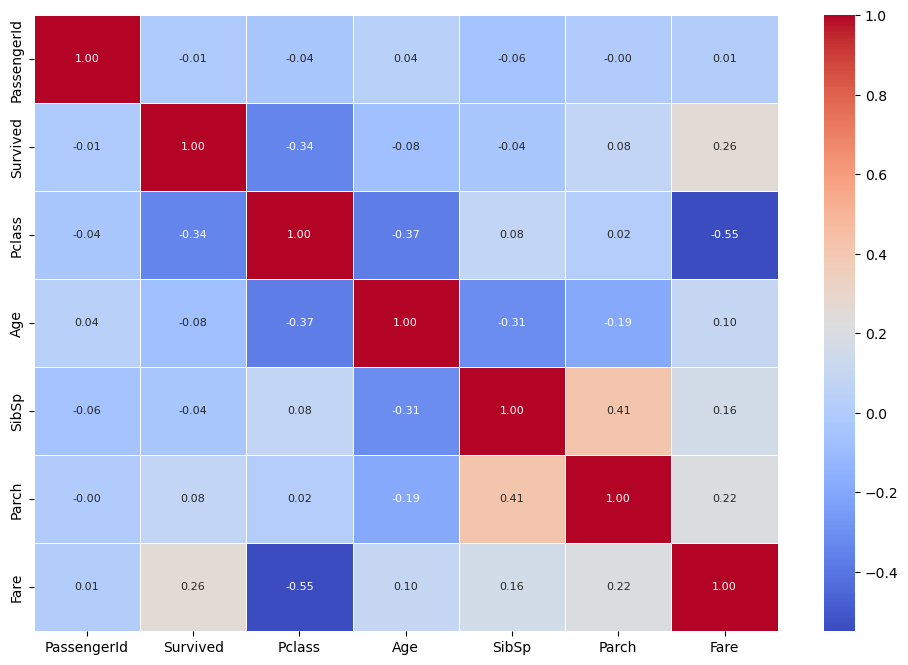

In [2]:
df = pd.read_csv("C:/Users/nooth/Downloads/archive (9)/Titanic-Dataset.csv")
df.head()
print(df.shape)# Check dataset dimensions (rows, columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())#to check missing values
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation = numeric_df.corr()
plt.figure(figsize=(12, 8))
# Heatmap to visualize relationships between variables
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5, annot_kws={"size":8})

In [3]:
# Drop high-missing and non-informative columns
df.drop(columns=['PassengerId', 'Ticket', 'Cabin'], inplace=True)

# Extract title from Name before dropping it
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(df['Title'].value_counts())

# Now drop Name
df.drop(columns=['Name'], inplace=True)

# Fill Age with median grouped by Title (more accurate than overall median)
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# Fill the 2 missing Embarked with the mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print(df.isnull().sum())
print(df.shape)

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
dtype: int64
(891, 9)


In [4]:
# Group rare titles into one category
df['Title'] = df['Title'].replace(
    ['Dr', 'Rev', 'Mlle', 'Major', 'Col', 'Countess',
     'Capt', 'Ms', 'Sir', 'Lady', 'Mme', 'Don', 'Jonkheer'], 'Rare'
)

print(df['Title'].value_counts())

# Feature engineering — family size tells more than SibSp/Parch separately
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Drop SibSp and Parch now that we have FamilySize
df.drop(columns=['SibSp', 'Parch'], inplace=True)

# Encode binary categoricals
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# One-hot encode Title and Embarked
df = pd.get_dummies(df, columns=['Title', 'Embarked'], drop_first=True)

print(df.shape)
print(df.dtypes)
print(df.head())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64
(891, 13)
Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
FamilySize      int64
IsAlone         int64
Title_Miss       bool
Title_Mr         bool
Title_Mrs        bool
Title_Rare       bool
Embarked_Q       bool
Embarked_S       bool
dtype: object
   Survived  Pclass  Sex   Age     Fare  FamilySize  IsAlone  Title_Miss  \
0         0       3    1  22.0   7.2500           2        0       False   
1         1       1    0  38.0  71.2833           2        0       False   
2         1       3    0  26.0   7.9250           1        1        True   
3         1       1    0  35.0  53.1000           2        0       False   
4         0       3    1  35.0   8.0500           1        1       False   

   Title_Mr  Title_Mrs  Title_Rare  Embarked_Q  Embarked_S  
0      True      False       False       False        True  
1     Fal

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert bool columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Separate features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — CRITICAL for SVM
# SVM is distance-based so unscaled features (e.g. Fare 0-512 vs IsAlone 0-1) will dominate unfairly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, not fit — avoids data leakage

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (712, 12)
Test shape: (179, 12)

Train target distribution:
 Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test target distribution:
 Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [6]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

[[99 11]
 [20 49]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       110
           1       0.82      0.71      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

ROC-AUC: 0.849802371541502


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

svm_base = SVC(probability=True, random_state=42)

grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV ROC-AUC: 0.8556


In [9]:
best_svm = grid_search.best_estimator_

y_pred = best_svm.predict(X_test_scaled)
y_pred_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Test Accuracy:", round(accuracy, 4))
print("Test ROC-AUC:", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8436
Test ROC-AUC: 0.859

Confusion Matrix:
[[99 11]
 [17 52]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       110
           1       0.83      0.75      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



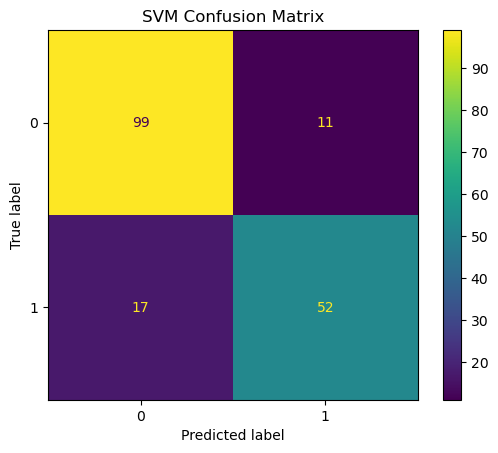

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("SVM Confusion Matrix")
plt.show()

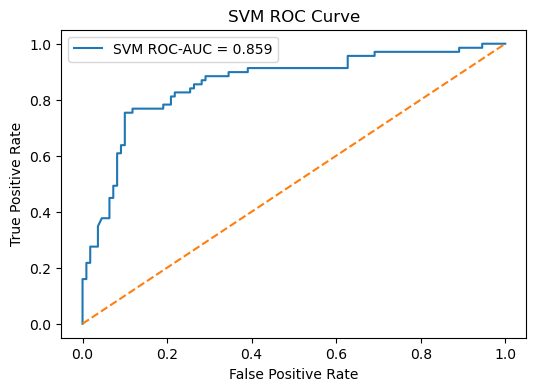

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"SVM ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

In [14]:
import joblib

joblib.dump(best_svm, "SVM_best_model.pkl")

print("SVM model saved successfully!")

SVM model saved successfully!
